<a href="https://colab.research.google.com/github/mirza-javed/ML-practice/blob/main/ML_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [9]:
df = pd.read_csv('/content/drive/MyDrive/ML Learning/Datasets/disease_prediction.csv')
df

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,24,Male,105,237,86,86,30.9,69,Yes,Yes,Medium,No,No
996,997,40,Male,120,219,133,72,34.3,92,Yes,Yes,Medium,No,No
997,998,44,Female,114,273,114,74,36.0,76,No,No,Low,No,Yes
998,999,31,Male,95,231,130,72,28.2,81,Yes,Yes,Medium,Yes,No


In [10]:
df.dtypes

,0
patient_id,int64
age,int64
gender,object
glucose_mg_dl,int64
cholesterol_mg_dl,int64
systolic_bp,int64
diastolic_bp,int64
bmi,float64
heart_rate,int64
smoking,object


In [11]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
glucose_mg_dl,0
cholesterol_mg_dl,0
systolic_bp,0
diastolic_bp,0
bmi,0
heart_rate,0
smoking,0


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()  # Create LabelEncoder

df['gender'] = le.fit_transform(df['gender'])  # Encode Gender column
df['smoking'] = le.fit_transform(df['smoking'])  # Encode smoking column
df['alcohol_consumption'] = le.fit_transform(df['alcohol_consumption'])  # Encode alcohol_consumption column
df['family_history'] = le.fit_transform(df['family_history'])  # Encode family_history column
df['disease'] = le.fit_transform(df['disease'])  # Encode disease column

df = pd.get_dummies(df, columns=['physical_activity'])

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cols_to_encode = ['physical_activity_High', 'physical_activity_Low', 'physical_activity_Medium']

for col in cols_to_encode:
    df[col] = le.fit_transform(df[col])

df.to_csv("/content/drive/MyDrive/ML Learning/Datasets/cleaned_disease_dataset.csv", index=False)  # Save updated dataset



In [13]:
df2 = pd.read_csv('/content/drive/MyDrive/ML Learning/Datasets/cleaned_disease_dataset.csv')
df2


,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,family_history,disease,physical_activity_High,physical_activity_Low,physical_activity_Medium
0,1,32,1,101,235,152,79,28.5,73,0,1,1,1,0,1,0
1,2,31,1,124,191,134,77,33.9,71,0,1,1,1,0,1,0
2,3,45,1,57,141,114,71,27.2,79,1,1,0,0,0,1,0
3,4,75,0,69,268,120,82,21.5,61,1,1,0,1,0,0,1
4,5,53,1,107,163,131,75,23.3,73,1,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,24,1,105,237,86,86,30.9,69,1,1,0,0,0,0,1
996,997,40,1,120,219,133,72,34.3,92,1,1,0,0,0,0,1
997,998,44,0,114,273,114,74,36.0,76,0,0,0,1,0,1,0
998,999,31,1,95,231,130,72,28.2,81,1,1,1,0,0,0,1


In [17]:
# Move 'disease' column to the end of df2
target = df2.pop('disease')
df2['disease'] = target

# Display the updated columns to verify
df2.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,family_history,physical_activity_High,physical_activity_Low,physical_activity_Medium,disease
0,1,32,1,101,235,152,79,28.5,73,0,1,1,0,1,0,1
1,2,31,1,124,191,134,77,33.9,71,0,1,1,0,1,0,1
2,3,45,1,57,141,114,71,27.2,79,1,1,0,0,1,0,0
3,4,75,0,69,268,120,82,21.5,61,1,1,0,0,0,1,1
4,5,53,1,107,163,131,75,23.3,73,1,0,1,0,1,0,1


In [18]:
# Re-assign X and y based on the updated column order
X = df2.drop('disease', axis=1)
y = df2['disease']

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,family_history,physical_activity_High,physical_activity_Low,physical_activity_Medium
0,1,32,1,101,235,152,79,28.5,73,0,1,1,0,1,0
1,2,31,1,124,191,134,77,33.9,71,0,1,1,0,1,0
2,3,45,1,57,141,114,71,27.2,79,1,1,0,0,1,0
3,4,75,0,69,268,120,82,21.5,61,1,1,0,0,0,1
4,5,53,1,107,163,131,75,23.3,73,1,0,1,0,1,0



Target (y) head:


,disease
0,1
1,1
2,0
3,1
4,1


In [23]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (800, 15)
Testing set shape: (200, 15)


In [24]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training and Testing with Logistic Regression Model

In [25]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [26]:
y_pred = model.predict(X_test)

In [27]:
y_test

,disease
521,1
737,1
740,0
660,1
411,0
...,...
408,0
332,1
208,0
613,0


In [28]:
y_pred

array([0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0])

In [32]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.8550

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       105
           1       0.87      0.82      0.84        95

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.85       200



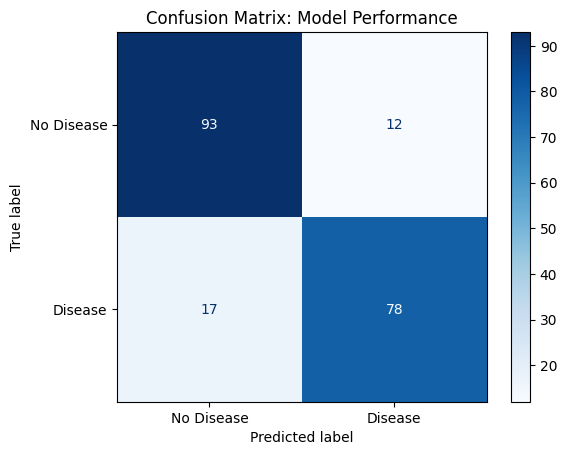

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Fixed: Use explicit labels since 'data.target_names' doesn't exist
# We sort the unique values of y to ensure 0 is first (No) and 1 is second (Yes)
display_labels = ['No Disease', 'Disease']

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

# Draw a plot
cm_display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Model Performance")
plt.show()

# Training and testing with Random Forest Classifier

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy Score: {rf_accuracy:.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy Score: 0.9300

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       105
           1       0.92      0.94      0.93        95

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



In [35]:
# Compare with previous results
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Random Forest Accuracy:       {rf_accuracy:.4f}")

Logistic Regression Accuracy: 0.8550
Random Forest Accuracy:       0.9300


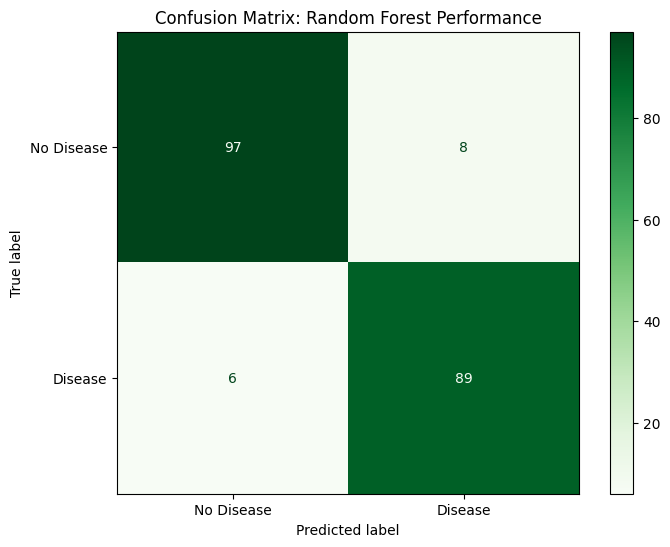

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Set display labels
display_labels = ['No Disease', 'Disease']

# Create the display
fig, ax = plt.subplots(figsize=(8, 6))
cm_display_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=display_labels)

# Plot the matrix
cm_display_rf.plot(cmap=plt.cm.Greens, ax=ax)
plt.title("Confusion Matrix: Random Forest Performance")
plt.show()

In [38]:
import joblib

# Save the Random Forest model to a file
joblib.dump(rf_model, 'random_forest_disease_model.joblib')

# Also save the scaler, as it's required for preprocessing future input data
joblib.dump(scaler, 'scaler.joblib')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


### How to load the model later:
To use the model in a different session, you would use:
```python
import joblib
# Load the model and scaler
loaded_model = joblib.load('random_forest_disease_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')

# Then you can make predictions on new data:
# new_data_scaled = loaded_scaler.transform(new_data)
# predictions = loaded_model.predict(new_data_scaled)
```

# Training with Decision Tree Classifier Model

In [39]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Initialize and train Decision Tree
# We'll set max_depth=4 to keep the visualization clear
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy Score: {dt_accuracy:.4f}")
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy Score: 0.8300

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.86      0.77      0.81        95

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



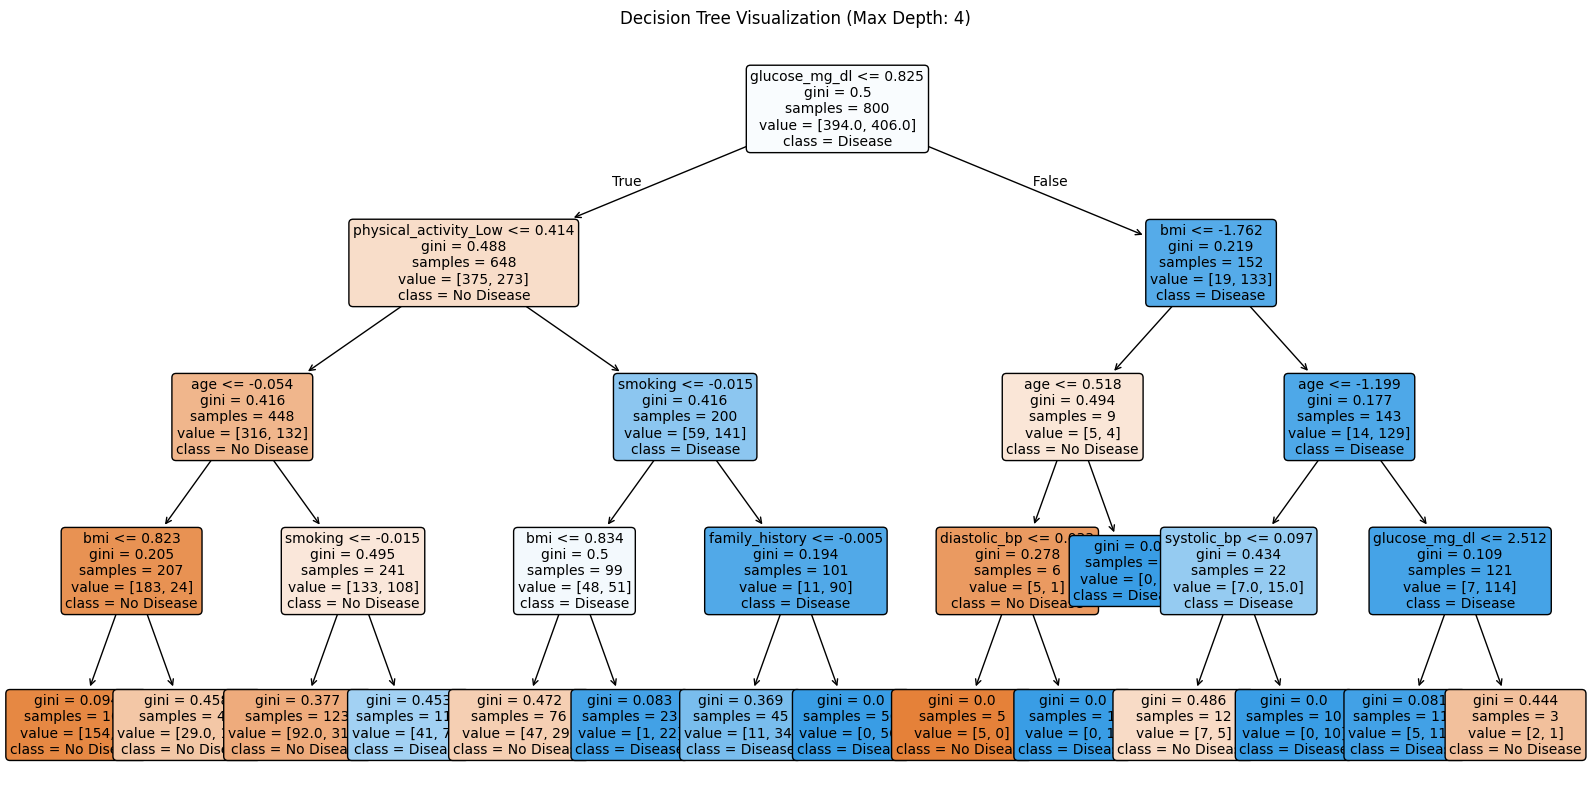

In [40]:
# Visualize the Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt_model,
          feature_names=X.columns.tolist(),
          class_names=['No Disease', 'Disease'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Visualization (Max Depth: 4)")
plt.show()

### Model Performance Comparison

| Model | Accuracy | Recall (Disease) | Precision (Disease) |
| :--- | :--- | :--- | :--- |
| **Random Forest** | **93.0%** | **0.94** | **0.92** |
| **Logistic Regression** | 85.5% | 0.82 | 0.87 |
| **Decision Tree (Depth 4)**| 83.0% | 0.77 | 0.86 |

**Analysis:** The Random Forest model remains the most robust choice for this dataset. The Decision Tree likely suffers from being too simple at a depth of 4, or would overfit if allowed to grow deeper, which is why the ensemble approach (Random Forest) works better here.